# Traffic Sign Detection

## Imports

In [51]:
import kagglehub
import os
from pathlib import Path
import cv2
import shutil
import matplotlib.pyplot as plt

## Loading in data

In [52]:
path = Path(kagglehub.dataset_download("pkdarabi/cardetection"))

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Dell\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5


In [53]:
folder_path = path / "car"
train_images_path = folder_path / "train" / "images"
train_labels_path = folder_path / "train" / "labels"
validation_images_path = folder_path / "valid" / "images"
validation_labels_path = folder_path / "valid" / "labels"
test_images_path = folder_path / "test" / "images"
test_labels_path = folder_path / "test" / "labels"

In [54]:
def load_images(folder_path):
    list_of_images = []
    for filename in os.listdir(folder_path):
        if filename.endswith((".jpg", ".png", ".jpeg")):
            img_path = os.path.join(folder_path, filename)
            
            img = cv2.imread(img_path)
            list_of_images.append(img)

    return list_of_images


In [55]:
train_images = load_images(train_images_path)
val_images = load_images(validation_images_path)
test_images = load_images(test_images_path)

## Data visualization

In [56]:
def show_annotated_image(img_path, label_path):
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Error: Could not load image from {img_path}")
        return
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    lbl_file = Path(label_path)
    lines = []
    if not lbl_file.exists():
        print(f"Info: No label file found for {img_path}")
    else:
        with open(lbl_file, 'r') as f:
            lines = f.readlines()

    for line in lines:
        parts = line.split()
        if len(parts) < 5:
            continue
            
        cls_id = parts[0]
        x_c, y_c, bw, bh = map(float, parts[1:5])
        
        x1 = int((x_c - bw/2) * w)
        y1 = int((y_c - bh/2) * h)
        x2 = int((x_c + bw/2) * w)
        y2 = int((y_c + bh/2) * h)
        
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, f"Class: {cls_id}", (x1, y1 - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    title_suffix = " (No Labels)" if not lbl_file.exists() else ""
    plt.title(f"{Path(img_path).name}{title_suffix}")
    plt.show()

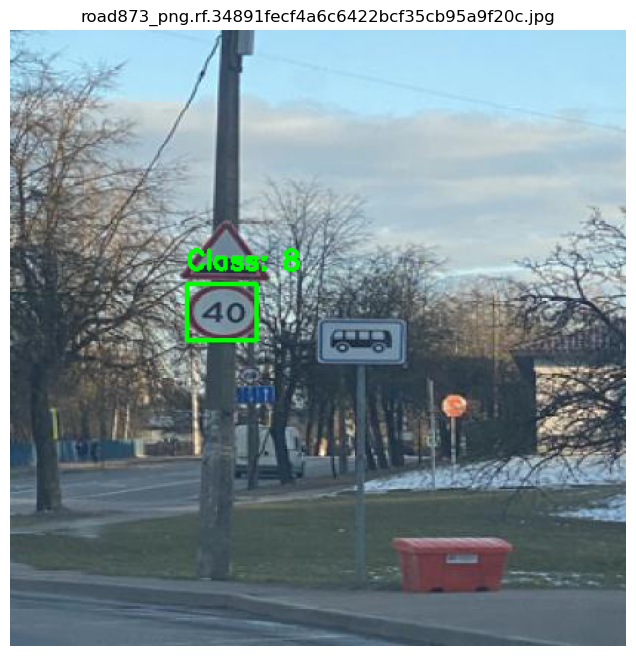

In [57]:
name = "road873_png.rf.34891fecf4a6c6422bcf35cb95a9f20c"
show_annotated_image(train_images_path / f"{name}.jpg", train_labels_path / f"{name}.txt")